#NN training without backpropagation
Uso de algoritmos de enjambre para entrenar una red neuronal (al menos de tres capas), o hallar los pesos y bias del modelo sin usar backpropagation.

##1. Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

##2. Carga del datset Iris


In [ ]:
data = load_iris()
X = data.data
y = data.target

# Convertir a problema binario (clase 0 vs resto)
y = (y == 0).astype(int).reshape(-1,1)

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Datos:", X.shape)

Datos: (150, 4)


Vamos a usar:

Entrada: 4

Oculta: 5

Salida: 1

Total de parámetros:

W1 = 4×5 = 20

b1 = 5

W2 = 5×1 = 5

b2 = 1

👉 Total = 31 parámetros

##4. Función de activación

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

##5. Forward pass

In [ ]:
def forward(weights, X):
    # Separar pesos
    W1 = weights[:20].reshape(4,5)
    b1 = weights[20:25].reshape(1,5)
    W2 = weights[25:30].reshape(5,1)
    b2 = weights[30:].reshape(1,1)

    hidden = sigmoid(np.dot(X, W1) + b1)
    output = sigmoid(np.dot(hidden, W2) + b2)

    return output

##6. Función de aptitud

In [ ]:
def fitness(weights):
    y_pred = forward(weights, X)
    return np.mean((y - y_pred)**2)

##7. Inicialización del enjambre

In [ ]:
n_particles = 30
dim = 31

particles = np.random.uniform(-1, 1, (n_particles, dim))
velocities = np.random.uniform(-0.1, 0.1, (n_particles, dim))

pbest = particles.copy()
pbest_scores = np.array([fitness(p) for p in particles])

gbest = particles[np.argmin(pbest_scores)]
gbest_score = np.min(pbest_scores)

print("Mejor error inicial:", gbest_score)

Mejor error inicial: 0.140752069447438


##8. Parámetros PSO

In [ ]:
w = 0.7
c1 = 1.5
c2 = 1.5

iterations = 60
error_history = []

##9. Entrenamiento (ciclo del enjambre)

In [ ]:
for iter in range(iterations):
    for i in range(n_particles):
        score = fitness(particles[i])

        if score < pbest_scores[i]:
            pbest[i] = particles[i]
            pbest_scores[i] = score

        if score < gbest_score:
            gbest = particles[i]
            gbest_score = score

    for i in range(n_particles):
        r1, r2 = np.random.rand(), np.random.rand()

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest[i] - particles[i])
            + c2 * r2 * (gbest - particles[i])
        )

        particles[i] += velocities[i]

    error_history.append(gbest_score)

    print(f"Iter {iter+1} - Error: {gbest_score}")

Iter 1 - Error: 0.140752069447438
Iter 2 - Error: 0.08686448244058691
Iter 3 - Error: 0.018267661475860272
Iter 4 - Error: 0.007003307230619577
Iter 5 - Error: 0.004764665539776144
Iter 6 - Error: 0.0035017548881438095
Iter 7 - Error: 0.0035017548881438095
Iter 8 - Error: 0.003202382368516127
Iter 9 - Error: 0.0028067052651980515
Iter 10 - Error: 0.0023703015031641154
Iter 11 - Error: 0.0023509186783155084
Iter 12 - Error: 0.0023327341221851695
Iter 13 - Error: 0.001975938674040496
Iter 14 - Error: 0.0015390381211978685
Iter 15 - Error: 0.0010012488407650372
Iter 16 - Error: 0.00045868162983533597
Iter 17 - Error: 1.589539829459573e-05
Iter 18 - Error: 2.2054543068591555e-08
Iter 19 - Error: 3.1091493315337554e-12
Iter 20 - Error: 8.476613590570761e-16
Iter 21 - Error: 5.486560824461555e-24
Iter 22 - Error: 4.0288757151110134e-30
Iter 23 - Error: 6.703756135842323e-39
Iter 24 - Error: 1.0617016907687637e-64
Iter 25 - Error: 6.28017704514137e-106
Iter 26 - Error: 1.962524814898714e-186


/tmp/ipykernel_13826/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Iter 38 - Error: 0.0
Iter 39 - Error: 0.0
Iter 40 - Error: 0.0
Iter 41 - Error: 0.0
Iter 42 - Error: 0.0
Iter 43 - Error: 0.0
Iter 44 - Error: 0.0
Iter 45 - Error: 0.0
Iter 46 - Error: 0.0
Iter 47 - Error: 0.0
Iter 48 - Error: 0.0
Iter 49 - Error: 0.0
Iter 50 - Error: 0.0
Iter 51 - Error: 0.0
Iter 52 - Error: 0.0
Iter 53 - Error: 0.0
Iter 54 - Error: 0.0
Iter 55 - Error: 0.0
Iter 56 - Error: 0.0
Iter 57 - Error: 0.0
Iter 58 - Error: 0.0
Iter 59 - Error: 0.0
Iter 60 - Error: 0.0


##10. Visualización del aprendizaje

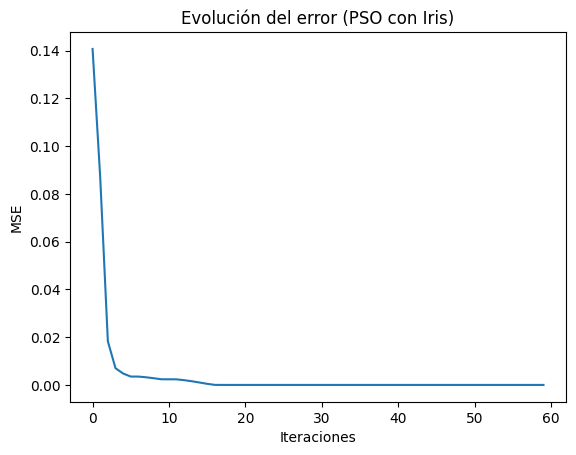

In [ ]:
plt.figure()
plt.plot(error_history)
plt.title("Evolución del error (PSO con Iris)")
plt.xlabel("Iteraciones")
plt.ylabel("MSE")
plt.show()

##11. Evaluación del modelo

In [ ]:
y_pred = forward(gbest, X)
y_pred_class = (y_pred > 0.5).astype(int)

accuracy = np.mean(y_pred_class == y)

print("\nAccuracy:", accuracy)


Accuracy: 1.0


/tmp/ipykernel_13826/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
